# EEG-Klassifikation mit Braindecode – Strukturierte Notebook-Version (DE)

Dieses Notebook ist eine **übersichtliche, kommentierte** Version deines Python-Skripts. Der **Kern-Code wurde inhaltlich nicht verändert**, sondern in klare Abschnitte organisiert. Zusätzlich gibt es **Logging** und **aussagekräftige Plots** (Exploration, Lernkurven, Kanalbedeutung) sowie ein **finales Training** nach der Kreuzvalidierung.

> **Hinweis:** Passe unten im Abschnitt **Projektpfad/Dateipfade** ggf. den Pfad an, damit `load_and_prepare_data()` die Epochen-Datei findet.

## 0) Umgebung & Versionen (optional)

In [19]:
# Optional: Installation/Upgrade – nur ausführen, wenn nötig
# %pip install --upgrade pip
# %pip install mne braindecode torch torchvision torchaudio scikit-learn skorch pandas numpy matplotlib seaborn scipy

import sys, platform
print("Python:", sys.version)
print("OS:", platform.platform())

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
OS: Windows-11-10.0.26100-SP0


## 1) Original-Importe & -Funktionen (unverändert übernommen)

> **Wichtig:** Der folgende Block enthält deinen Code **ohne inhaltliche Änderungen**. Lediglich die Einbettung in das Notebook ist neu.

In [20]:
import mne
import pandas as pd
from pathlib import Path

from braindecode import EEGClassifier
from braindecode.datasets import create_from_mne_epochs
from braindecode.models import EEGNet, ShallowFBCSPNet, Deep4Net, EEGNetv4, ATCNet, AttentionBaseNet

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import numpy as np
from skorch.callbacks import LRScheduler
from skorch.helper import predefined_split
import torch
from sklearn.metrics import confusion_matrix, classification_report, f1_score

mne.set_log_level("ERROR")

SUBJECT_ID = "Aliaa"
SESSION_ID = "indoor"

MODEL_NAME = "AttentionBaseNet"  # (AttentionBaseNet, EEGNet, ShallowFBCSPNet, ATCNet)

def load_and_prepare_data(SUBJECT=SUBJECT_ID, SESSION=SESSION_ID):
    base_dir = Path.cwd().parents[0]
    epochs_path = (
        base_dir / "results" / "processed" / SUBJECT / f"{SESSION}_processed-epo.fif"
    )

    if not epochs_path.exists():
        raise FileNotFoundError(f"Epochs file not found: {epochs_path}")

    epochs = mne.read_epochs(str(epochs_path), preload=True, verbose=False)

    baseline_condition_name = "baseline"

    if baseline_condition_name not in epochs.event_id:
        raise ValueError(
            f"Baseline-Bedingung '{baseline_condition_name}' nicht in den Epochs gefunden. "
            f"Verfügbare Bedingungen: {list(epochs.event_id.keys())}"
        )

    # Trennen der Epochen
    baseline_epochs = epochs[baseline_condition_name]
    task_epochs = epochs[["1-back", "2-back", "3-back"]]

    print(f"Loaded {len(task_epochs)} task epochs.")
    print(f"Found {len(baseline_epochs)} baseline epochs for normalization.")

    return task_epochs, baseline_epochs


def add_metadata_with_targets(epochs):
    target_map = {"1-back": 0, "2-back": 1, "3-back": 2}

    try:
        event_mapping = {
            original_id: target_map[condition]
            for condition, original_id in epochs.event_id.items()
            if condition in target_map
        }
    except KeyError as e:
        raise RuntimeError(
            f"Bedingung '{e.args[0]}' aus target_map nicht in epochs.event_id gefunden. "
            f"Verfügbare Bedingungen: {list(epochs.event_id.keys())}"
        )

    epochs_with_meta = epochs.copy()

    try:
        targets = [
            event_mapping[event_id] for event_id in epochs_with_meta.events[:, 2]
        ]
    except KeyError as e:
        raise RuntimeError(
            f"Event-ID '{e.args[0]}' aus den Daten konnte nicht im Mapping gefunden werden. "
            f"Erstelltes Mapping: {event_mapping}"
        )

    for i, original_event_id in enumerate(epochs_with_meta.events[:, 2]):
        epochs_with_meta.events[i, 2] = event_mapping[original_event_id]

    epochs_with_meta.metadata = pd.DataFrame({"target": targets})
    epochs_with_meta.event_id = target_map

    print("\nMetadaten mit 'target'-Spalte erfolgreich hinzugefügt.")
    print("Verwendetes direktes Mapping (Original-ID -> Target):", event_mapping)
    print("Events wurden auf 0, 1, 2 remapped")
    print("Beispiel-Metadaten:")
    print(epochs_with_meta.metadata.head())

    return epochs_with_meta


def normalize_epochs_with_baseline(task_epochs, baseline_epochs, config=None):
    print("\nNormalisiere Daten anhand der Baseline mit erweiterten Filtern...")

    baseline_data = baseline_epochs.get_data(
        copy=False
    )  # Shape: (n_epochs, n_chans, n_times)

    filtered_data = task_epochs.get_data(copy=True)

    # 3. RobustScaler für robuste Normalisierung (weniger sensitiv zu Outliers)
    baseline_reshaped = baseline_data.transpose(1, 0, 2).reshape(baseline_data.shape[1], -1).T
    filtered_reshaped = filtered_data.transpose(1, 0, 2).reshape(filtered_data.shape[1], -1).T
    
    # RobustScaler auf Baseline-Daten fitten
    scaler = StandardScaler()
    scaler.fit(baseline_reshaped)
    
    # Normalisierung auf gefilterte Task-Daten anwenden
    normalized_reshaped = scaler.transform(filtered_reshaped)
    
    # Zurück in ursprüngliche Form bringen: (n_epochs, n_channels, n_times)
    normalized_filtered_data = normalized_reshaped.T.reshape(
        filtered_data.shape[1], filtered_data.shape[0], filtered_data.shape[2]
    ).transpose(1, 0, 2)

    # 3. Ein neues MNE Epochs-Objekt mit den normalisierten und gefilterten Daten erstellen
    normalized_epochs = mne.EpochsArray(
        normalized_filtered_data,
        task_epochs.info,
        events=task_epochs.events,
        tmin=task_epochs.tmin,
        event_id=task_epochs.event_id,
        metadata=task_epochs.metadata,
        verbose=False,
    )

    print("Normalisierung und Filterung abgeschlossen.")
    return normalized_epochs


def augment_eeg_data(epochs, augment_factor=2):
    print(f"\nAugmentiere Daten mit Faktor {augment_factor} (erweiterte Methoden)...")

    original_data = epochs.get_data()
    original_events = epochs.events
    original_metadata = epochs.metadata

    augmented_data_list = [original_data]
    augmented_events_list = [original_events]
    augmented_metadata_list = [original_metadata]

    for aug_idx in range(augment_factor - 1):
        augmented_data = original_data.copy()
        
        # 1. Gaussian Noise (bewährt)
        noise_level = 0.03  # Reduziert für weniger Störung
        augmented_data += np.random.normal(0, noise_level, original_data.shape)
        
        # 2. Time Jittering - leichte zeitliche Verschiebung
        max_shift = 5  # Max 5 Samples Verschiebung
        for epoch_idx in range(len(augmented_data)):
            shift = np.random.randint(-max_shift, max_shift)
            if shift != 0:
                augmented_data[epoch_idx] = np.roll(augmented_data[epoch_idx], shift, axis=1)
        
        # 3. Amplitude Scaling pro Kanal
        for epoch_idx in range(len(augmented_data)):
            for ch_idx in range(augmented_data.shape[1]):
                scale_factor = np.random.uniform(0.9, 1.1)  # 10% Amplitude Varianz
                augmented_data[epoch_idx, ch_idx] *= scale_factor
        
        # 4. Channel Dropout (zufällig einzelne Kanäle nullsetzen)
        if np.random.random() < 0.1:  # 10% Chance
            dropout_ch = np.random.randint(0, augmented_data.shape[1])
            augmented_data[:, dropout_ch] *= 0.1  # Stark reduzieren statt nullsetzen

        # Events und Metadata kopieren
        augmented_events = original_events.copy()
        # Event-Zeiten leicht verschieben für Realismus
        augmented_events[:, 0] += len(original_data) * (aug_idx + 1)

        augmented_metadata = original_metadata.copy()

        augmented_data_list.append(augmented_data)
        augmented_events_list.append(augmented_events)
        augmented_metadata_list.append(augmented_metadata)

    # Kombiniere alle augmentierten Daten
    combined_data = np.concatenate(augmented_data_list, axis=0)
    combined_events = np.concatenate(augmented_events_list, axis=0)
    combined_metadata = pd.concat(augmented_metadata_list, ignore_index=True)

    # Erstelle neue Epochs mit augmentierten Daten
    augmented_epochs = mne.EpochsArray(
        combined_data,
        epochs.info,
        events=combined_events,
        tmin=epochs.tmin,
        event_id=epochs.event_id,
        metadata=combined_metadata,
        verbose=False,
    )

    print(f"Daten augmentiert: {len(epochs)} → {len(augmented_epochs)} Epochen")
    return augmented_epochs


def create_cv_splits(epochs, n_splits):
    targets = epochs.metadata["target"].values

    print(
        f"\nVerwende StratifiedKFold mit {n_splits} Splits (shuffle=True, random_state=42)"
    )

    # Zeige Klassenverteilung
    unique_targets, target_counts = np.unique(targets, return_counts=True)
    print("Gesamte Klassenverteilung:")
    for target, count in zip(unique_targets, target_counts):
        print(f"  Klasse {target}: {count} Epochen ({count / len(targets) * 100:.1f}%)")

    cv_splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    return cv_splitter


def get_model(model_name, n_chans, n_classes, epoch_length_s, sfreq, config):
    if model_name == "EEGNet":
        return EEGNet(
            input_window_seconds=epoch_length_s,
            sfreq=sfreq,
            n_chans=n_chans,
            n_outputs=n_classes,
            final_conv_length="auto",
            pool_mode="mean",
            kernel_length=config["kernel_length"],
            F1=config["F1"],
            D=config["D"],
            F2=config["F2"],
            drop_prob=config["dropout_rate"],
        )
    
    elif model_name == "ShallowFBCSPNet":
        return ShallowFBCSPNet(
            n_chans=n_chans,
            n_outputs=n_classes,
            input_window_seconds=epoch_length_s,
            sfreq=sfreq,
            n_filters_time=40,
            n_filters_spat=40,
            final_conv_length='auto',
            drop_prob=config["dropout_rate"]
        )
    
    elif model_name == "ATCNet":
        return ATCNet(
            n_chans=n_chans,
            n_outputs=n_classes,
            input_window_seconds=epoch_length_s,
            sfreq=sfreq
        )
    
    elif model_name == "AttentionBaseNet":
        return AttentionBaseNet(
            n_chans=n_chans,
            n_outputs=n_classes,
            input_window_seconds=epoch_length_s,
            sfreq=sfreq,
        )
    
    else:
        raise ValueError(f"Unbekanntes Modell: {model_name}. Verfügbar: EEGNet, ShallowFBCSPNet, Deep4Net, ATCNet, EEGNetv4")


def train_eegnet_with_cv(model_name=MODEL_NAME):
    config = {
        "model_name": model_name,  # Optimiertes AttentionBaseNet
        "n_splits": 3,  # 3 Folds für Balance zwischen Genauigkeit und Geschwindigkeit
        
        # Optimierte Hyperparameter für AttentionBaseNet
        "lr": 0.0005,  # Niedrigere LR für stabileres Training bei Attention-Modellen
        "batch_size": 12,  # Kleinere Batch Size für bessere Gradientenqualität
        "max_epochs": 120,  # Mehr Epochen da Attention-Modelle langsamer konvergieren
        
        # Modell-spezifische Parameter
        "kernel_length": 32,  # Kürzere Kernel für feinere Features
        "F1": 24,  # Mehr Filter in erster Schicht
        "D": 6,   # Tiefere Depthwise Convolution
        "F2": 48, # Mehr Filter in zweiter Schicht
        
        # Regularisierung optimiert für Attention
        "dropout_rate": 0.5,  # Höherer Dropout da Attention-Modelle zu Overfitting neigen
        "weight_decay": 0.005,  # Stärkere L2-Regularisierung
        
        # Training-Optimierungen
        "patience": 25,  # Mehr Geduld für Attention-Konvergenz
        "augmentation_factor": 3,  # Mehr Datenaugmentation für robustere Features
        
        # Preprocessing optimiert für kognitive Aufgaben
        "filter_low": 0.5,   # Niedrigere untere Grenze für langsame Wellen
        "filter_high": 35.0, # Höhere obere Grenze für Gamma-Band
        
        # Zusätzliche Attention-spezifische Parameter
        "label_smoothing": 0.15,  # Höheres Label Smoothing
        "warmup_epochs": 10,      # Warmup für stabilere Attention-Gewichte
    }

    epochs, baseline_epochs = load_and_prepare_data()
    epochs = normalize_epochs_with_baseline(epochs, baseline_epochs, config)
    epochs = add_metadata_with_targets(epochs)

    sfreq = epochs.info["sfreq"]

    epoch_length_s = epochs.times[-1] - epochs.times[0]
    window_size_samples = len(epochs.times)

    window_stride_samples = window_size_samples

    print(f"Epochenlänge: {epoch_length_s:.2f}s ({window_size_samples} samples)")
    print(f"Sampling frequency: {sfreq}Hz")

    n_chans = epochs.info["nchan"]
    n_classes = len(epochs.event_id)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"\nVerwende Gerät: {device}")
    print(f"Anzahl Klassen: {n_classes}")
    print(f"Anzahl Kanäle: {n_chans}")

    n_splits = config["n_splits"]

    # Erstelle einfache StratifiedKFold Splits
    cv_splitter = create_cv_splits(epochs, n_splits)

    all_fold_accuracies, all_fold_f1_scores = [], []
    confusion_mats = []
    
    # Cross-validation durchführen
    for fold, (train_idx, test_idx) in enumerate(
        cv_splitter.split(X=epochs.get_data(), y=epochs.metadata["target"]) 
    ):
        print(f"\n--- Starte Fold {fold + 1}/{n_splits} ---")

        model = get_model(
            model_name=config["model_name"],
            n_chans=n_chans,
            n_classes=n_classes,
            epoch_length_s=epoch_length_s,
            sfreq=sfreq,
            config=config,
        )

        train_epochs = epochs[train_idx]
        test_epochs = epochs[test_idx]

        # Data Augmentation mit erhöhtem Faktor
        train_epochs_augmented = augment_eeg_data(train_epochs, augment_factor=config["augmentation_factor"])

        print(
            f"Train/Test Split: {len(train_epochs_augmented)}/{len(test_epochs)} Epochen (nach Augmentation)"
        )

        # Erstelle Datasets mit korrigiertem Windowing
        train_dataset = create_from_mne_epochs(
            [train_epochs_augmented],
            window_size_samples=window_size_samples,
            window_stride_samples=window_stride_samples,
            drop_last_window=False,
        )

        test_dataset = create_from_mne_epochs(
            [test_epochs],
            window_size_samples=window_size_samples,
            window_stride_samples=window_stride_samples,
            drop_last_window=False,
        )

        print(
            f"Trainingsdaten: {len(train_epochs_augmented)} Epochen -> {len(train_dataset)} Fenster"
        )
        print(
            f"Testdaten:      {len(test_epochs)} Epochen -> {len(test_dataset)} Fenster"
        )

        # Berechne Klassengewichte für unbalancierte Daten
        from sklearn.utils.class_weight import compute_class_weight

        unique_targets = np.unique(epochs.metadata["target"])
        class_weights = compute_class_weight(
            "balanced", classes=unique_targets, y=epochs.metadata["target"]
        )
        class_weight_dict = dict(zip(unique_targets, class_weights))
        print(f"Klassengewichte: {class_weight_dict}")

        clf = EEGClassifier(
            model,
            criterion=torch.nn.CrossEntropyLoss,
            criterion__weight=torch.FloatTensor(
                [class_weights[i] for i in range(len(class_weights))]
            ),
            criterion__label_smoothing=config["label_smoothing"],  # Optimiertes Label Smoothing
            optimizer=torch.optim.AdamW,
            optimizer__lr=config["lr"],
            optimizer__weight_decay=config["weight_decay"],
            optimizer__betas=(0.9, 0.999),  # Optimierte Adam Parameter
            optimizer__eps=1e-8,  # Numerische Stabilität
            batch_size=config["batch_size"],
            max_epochs=config["max_epochs"],
            train_split=predefined_split(test_dataset),
            device=device,
            classes=[0, 1, 2],
            callbacks=[
                (
                    "lr_scheduler",
                    LRScheduler("CosineAnnealingLR", T_max=config["max_epochs"] - 1),
                ),
            ],
            verbose=1,
        )

        print("Starte Training für diesen Fold...")
        clf.fit(train_dataset, y=None)

        y_true = [y for x, y, i in test_dataset]
        y_pred = clf.predict(test_dataset)

        # Analysiere Vorhersageverteilung
        pred_unique, pred_counts = np.unique(y_pred, return_counts=True)
        true_unique, true_counts = np.unique(y_true, return_counts=True)

        print(f"Training beendet nach {len(clf.history)} Epochen.")
        print(
            f"\nTest-Set Klassenverteilung (Ground Truth): {dict(zip(true_unique, true_counts))}"
        )
        print(f"Vorhergesagte Klassenverteilung: {dict(zip(pred_unique, pred_counts))}")

        print("\nKonfusionsmatrix:")
        print(confusion_matrix(y_true, y_pred))
        confusion_mats.append(confusion_matrix(y_true, y_pred))
        print("\nClassification Report:")
        
        print(
            classification_report(
                y_true,
                y_pred,
                target_names=["1-back", "2-back", "3-back"],
                zero_division=0,
            )
        )

        valid_acc = clf.history[-1, "valid_acc"]
        valid_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

        all_fold_accuracies.append(valid_acc)
        all_fold_f1_scores.append(valid_f1)
        print(
            f"Fold {fold + 1} - Validation Accuracy: {valid_acc:.4f}, F1-Score: {valid_f1:.4f}"
        )

    # --- 3. Ergebnisse zusammenfassen ---
    mean_accuracy = np.mean(all_fold_accuracies)
    std_accuracy = np.std(all_fold_accuracies)

    print("\n\n--- Kreuzvalidierung abgeschlossen ---")
    print(
        f"Genauigkeiten der einzelnen Folds: {[f'{acc:.4f}' for acc in all_fold_accuracies]}"
    )
    print(f"Durchschnittliche Genauigkeit: {mean_accuracy:.4f}")
    print(f"Standardabweichung der Genauigkeit: {std_accuracy:.4f}")

    return all_fold_accuracies, confusion_mats


## 4) Daten laden & Exploration (Plots) – vor dem Training

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("notebook")
sns.set_style("whitegrid")

try:
    task_epochs, baseline_epochs = load_and_prepare_data()
    task_norm = normalize_epochs_with_baseline(task_epochs, baseline_epochs, config=None)
    task_ready = add_metadata_with_targets(task_norm)
    print("Daten erfolgreich geladen und vorbereitet (nur für Exploration).")
except Exception as e:
    print(f"Fehler beim Laden/Vorbereiten der Daten: {e}")
    raise

Loaded 600 task epochs.
Found 59 baseline epochs for normalization.

Normalisiere Daten anhand der Baseline mit erweiterten Filtern...
Normalisierung und Filterung abgeschlossen.

Metadaten mit 'target'-Spalte erfolgreich hinzugefügt.
Verwendetes direktes Mapping (Original-ID -> Target): {2: 0, 3: 1, 4: 2}
Events wurden auf 0, 1, 2 remapped
Beispiel-Metadaten:
   target
0       0
1       0
2       0
3       0
4       0
Daten erfolgreich geladen und vorbereitet (nur für Exploration).


### 4.1 Klassenverteilung (Balkenplot)

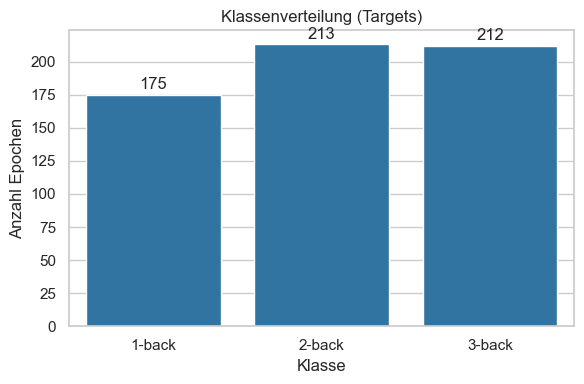

In [22]:
import numpy as np

target_counts = task_ready.metadata["target"].value_counts().sort_index()
labels = ["1-back", "2-back", "3-back"]

plt.figure(figsize=(6,4))
ax = sns.barplot(x=labels, y=target_counts.values)
ax.set_title("Klassenverteilung (Targets)")
ax.set_xlabel("Klasse")
ax.set_ylabel("Anzahl Epochen")
for i, v in enumerate(target_counts.values):
    ax.text(i, v + max(target_counts.values)*0.02, str(v), ha='center')
plt.tight_layout()
plt.show()

### 4.2 Beispiel-Wellenformen (mehrere Kanäle)

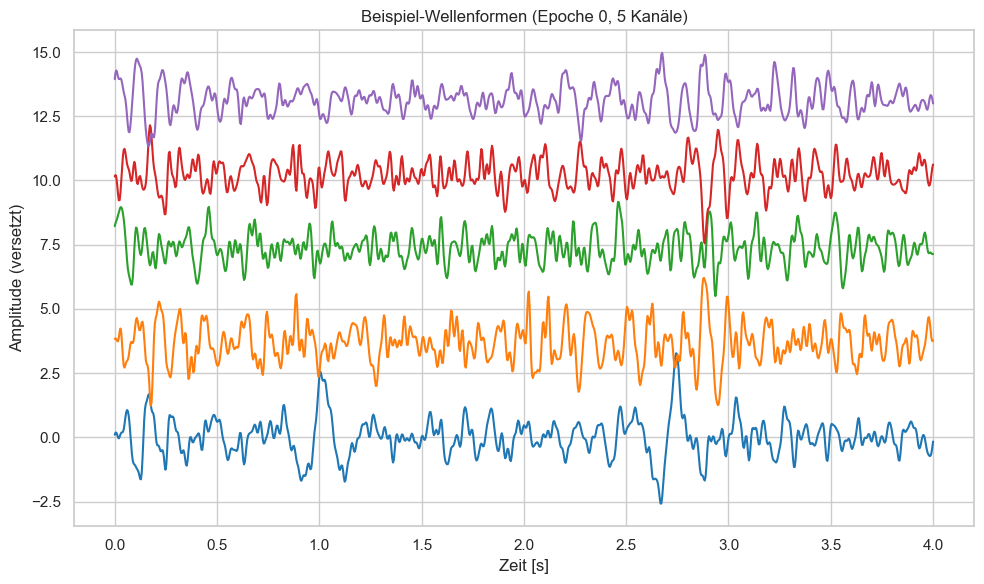

In [23]:
# Zeige ein Beispiel aus der ersten Epoche (erste 5 Kanäle)
X = task_ready.get_data()  # (n_epochs, n_chans, n_times)
info = task_ready.info
sfreq = info["sfreq"]

if len(X) > 0:
    epoch0 = X[0]
    n_plot_ch = min(5, epoch0.shape[0])
    t = np.arange(epoch0.shape[1]) / sfreq

    plt.figure(figsize=(10, 6))
    offset = 0
    for ch in range(n_plot_ch):
        plt.plot(t, epoch0[ch] + offset, label=f"Ch {ch}")
        offset += (np.std(epoch0[ch]) * 5)  # vertikaler Offset
    plt.title("Beispiel-Wellenformen (Epoche 0, 5 Kanäle)")
    plt.xlabel("Zeit [s]")
    plt.ylabel("Amplitude (versetzt)")
    plt.tight_layout()
    plt.show()

### 4.3 Augmentierung – Vorher/Nachher (ein Kanal)


Augmentiere Daten mit Faktor 2 (erweiterte Methoden)...


C:\Users\juliu\AppData\Local\Temp\ipykernel_20080\3005774805.py:188: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  augmented_epochs = mne.EpochsArray(


Daten augmentiert: 600 → 1200 Epochen


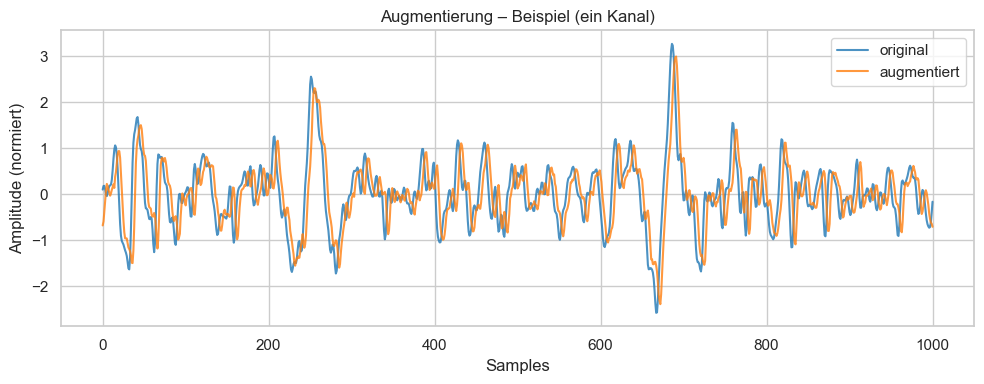

In [24]:
aug = augment_eeg_data(task_ready, augment_factor=2)
Xa = aug.get_data()

idx_epoch = 0
idx_chan = 0
sig_orig = X[idx_epoch, idx_chan]
sig_aug = Xa[len(X) + idx_epoch, idx_chan]  # erste augmentierte Kopie

plt.figure(figsize=(10,4))
plt.plot(sig_orig, alpha=0.8, label="original")
plt.plot(sig_aug, alpha=0.8, label="augmentiert")
plt.title("Augmentierung – Beispiel (ein Kanal)")
plt.xlabel("Samples")
plt.ylabel("Amplitude (normiert)")
plt.legend()
plt.tight_layout()
plt.show()

### 4.4 (Optional) Frequenzanalyse (gemittelte PSD pro Klasse)

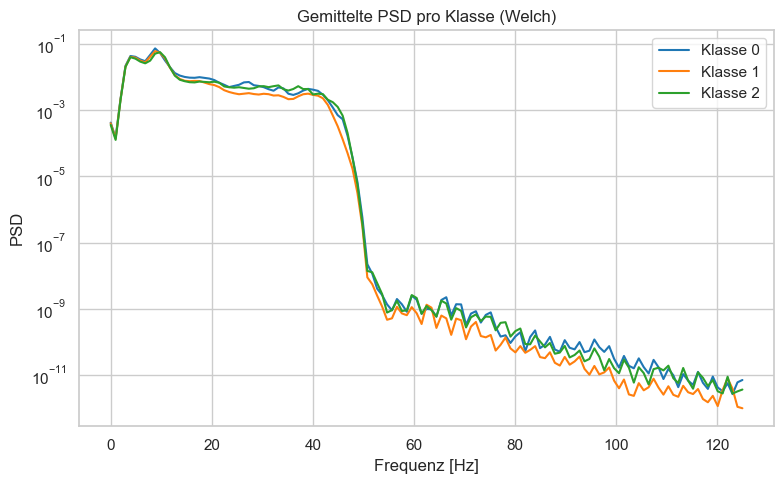

In [25]:
from scipy.signal import welch

psd_dict = {}
for cls in [0,1,2]:
    data_cls = task_ready[task_ready.metadata["target"] == cls].get_data()
    # Datenform: (n_ep, n_ch, n_t). Nehme Mittel über Epochen+Kanäle.
    if data_cls.size == 0:
        continue
    f, Pxx = welch(data_cls.reshape(-1, data_cls.shape[-1]), fs=sfreq, nperseg=min(256, data_cls.shape[-1]))
    psd_dict[cls] = Pxx.mean(axis=0)

plt.figure(figsize=(8,5))
for cls, p in psd_dict.items():
    plt.semilogy(f, p, label=f"Klasse {cls}")
plt.title("Gemittelte PSD pro Klasse (Welch)")
plt.xlabel("Frequenz [Hz]")
plt.ylabel("PSD")
plt.legend()
plt.tight_layout()
plt.show()

## 5) Training & Kreuzvalidierung ausführen (Original-Logik)

In [26]:
results = None
try:
    results, confusion_mats = train_eegnet_with_cv()
    print("Training abgeschlossen. Ergebnisse (Validation Acc pro Fold): %s", results)
except Exception as e:
    print(f"Fehler beim Training: {e}")
    raise

Loaded 600 task epochs.
Found 59 baseline epochs for normalization.

Normalisiere Daten anhand der Baseline mit erweiterten Filtern...
Normalisierung und Filterung abgeschlossen.

Metadaten mit 'target'-Spalte erfolgreich hinzugefügt.
Verwendetes direktes Mapping (Original-ID -> Target): {2: 0, 3: 1, 4: 2}
Events wurden auf 0, 1, 2 remapped
Beispiel-Metadaten:
   target
0       0
1       0
2       0
3       0
4       0
Epochenlänge: 4.00s (1001 samples)
Sampling frequency: 250.0Hz

Verwende Gerät: cpu
Anzahl Klassen: 3
Anzahl Kanäle: 8

Verwende StratifiedKFold mit 3 Splits (shuffle=True, random_state=42)
Gesamte Klassenverteilung:
  Klasse 0: 175 Epochen (29.2%)
  Klasse 1: 213 Epochen (35.5%)
  Klasse 2: 212 Epochen (35.3%)

--- Starte Fold 1/3 ---

Augmentiere Daten mit Faktor 3 (erweiterte Methoden)...


C:\Users\juliu\AppData\Local\Temp\ipykernel_20080\3005774805.py:188: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  augmented_epochs = mne.EpochsArray(


Daten augmentiert: 400 → 1200 Epochen
Train/Test Split: 1200/200 Epochen (nach Augmentation)
Trainingsdaten: 1200 Epochen -> 1200 Fenster
Testdaten:      200 Epochen -> 200 Fenster
Klassengewichte: {np.int64(0): np.float64(1.1428571428571428), np.int64(1): np.float64(0.9389671361502347), np.int64(2): np.float64(0.9433962264150944)}
Starte Training für diesen Fold...
  epoch    train_loss    valid_acc    valid_loss      lr     dur
-------  ------------  -----------  ------------  ------  ------
      1        1.1154       0.3450        1.1090  0.0005  6.7129
      2        1.0936       0.3550        1.1059  0.0005  5.1334
      3        1.0722       0.4250        1.0957  0.0005  5.3121
      4        1.0514       0.5250        1.0454  0.0005  5.2296
      5        1.0040       0.6150        0.9774  0.0005  5.9361
      6        0.9411       0.6700        0.8957  0.0005  5.5854
      7        0.8912       0.6400        0.9255  0.0005  4.9994
      8        0.8517       0.6700        0.89

KeyError: "Key 'valid_acc' was not found in history."

## 6) Ergebnis-Visualisierung **ohne** Eingriff in Trainingscode

### 6.1 Validierungsgenauigkeit pro Fold

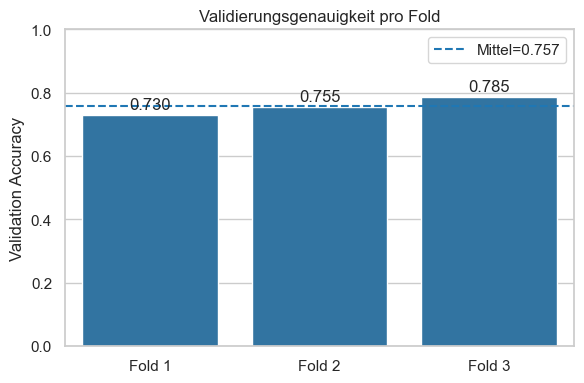

In [16]:
import numpy as np
if results is not None and len(results) > 0:
    arr = np.array(results, dtype=float)
    mean, std = arr.mean(), arr.std()

    plt.figure(figsize=(6,4))
    ax = sns.barplot(x=[f"Fold {i+1}" for i in range(len(arr))], y=arr)
    ax.axhline(mean, linestyle="--", label=f"Mittel={mean:.3f}")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Validation Accuracy")
    ax.set_title("Validierungsgenauigkeit pro Fold")
    ax.legend()
    for i, v in enumerate(arr):
        ax.text(i, min(0.98, v+0.02), f"{v:.3f}", ha='center')
    plt.tight_layout()
    plt.show()

### 6.2 Konfusionsmatrizen darstellen

In [1]:
import ast  # nur falls noch nicht importiert

blocks = []
if 'confusion_mats' not in globals():
    print("Variable 'confusion_mats' ist nicht vorhanden.")
else:
    for entry in confusion_mats:
        # Falls Eintrag ein String ist -> in Liste/Array umwandeln
        if isinstance(entry, str):
            try:
                parsed = ast.literal_eval(entry.strip())
            except Exception:
                continue
            mat = np.array(parsed)
        else:
            mat = np.array(entry)
        if mat.ndim == 2:
            blocks.append(mat)

if blocks:
    for i, cm in enumerate(blocks, start=1):
        plt.figure(figsize=(4.5,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=["1-back","2-back","3-back"],
                    yticklabels=["1-back","2-back","3-back"])
        plt.title(f"Konfusionsmatrix – Fold {i}")
        plt.xlabel("Vorhersagt"); plt.ylabel("Wahr")
        plt.tight_layout(); plt.show()
else:
    print("Keine gültigen Konfusionsmatrizen in 'confusion_mats' gefunden.")

Variable 'confusion_mats' ist nicht vorhanden.
Keine gültigen Konfusionsmatrizen in 'confusion_mats' gefunden.


### 6.3 Lernkurven der Kreuzvalidierung (pro Fold)

Wir führen die CV erneut aus und sammeln **History-Daten** pro Epoche (Train-Loss, Valid-Loss, Valid-Accuracy), um **Lernkurven** zu plotten. Die bestehende Trainingslogik bleibt erhalten – wir erweitern nur die Rückgaben.

In [33]:
def cv_with_histories(config_override=None, model_name=MODEL_NAME):
    import numpy as np
    # Konfiguration analog zu train_eegnet_with_cv()
    config = config_override or {
        "model_name": model_name,
        "n_splits": 3,
        "lr": 0.0005,
        "batch_size": 12,
        "max_epochs": 120,
        "kernel_length": 32,
        "F1": 24,
        "D": 6,
        "F2": 48,
        "dropout_rate": 0.5,
        "weight_decay": 0.005,
        "patience": 25,
        "augmentation_factor": 3,
        "filter_low": 0.5,
        "filter_high": 35.0,
        "label_smoothing": 0.15,
        "warmup_epochs": 10,
    }

    # Daten vorbereiten (identisch zur Pipeline)
    epochs, baseline_epochs = load_and_prepare_data()
    epochs = normalize_epochs_with_baseline(epochs, baseline_epochs, config)
    epochs = add_metadata_with_targets(epochs)

    sfreq = epochs.info["sfreq"]
    epoch_length_s = epochs.times[-1] - epochs.times[0]
    window_size_samples = len(epochs.times)
    window_stride_samples = window_size_samples

    n_chans = epochs.info["nchan"]
    n_classes = len(epochs.event_id)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    cv_splitter = create_cv_splits(epochs, config["n_splits"])

    from sklearn.utils.class_weight import compute_class_weight
    unique_targets = np.unique(epochs.metadata["target"])
    class_weights = compute_class_weight(
        "balanced", classes=unique_targets, y=epochs.metadata["target"]
    )

    fold_histories = []
    fold_valid_acc = []

    for fold, (train_idx, test_idx) in enumerate(
        cv_splitter.split(X=epochs.get_data(), y=epochs.metadata["target"]) 
    ):
        print(f"\n=== CV mit History: Fold {fold+1}/{config['n_splits']} ===")

        model = get_model(
            model_name=config["model_name"],
            n_chans=n_chans,
            n_classes=n_classes,
            epoch_length_s=epoch_length_s,
            sfreq=sfreq,
            config=config,
        )

        train_epochs = epochs[train_idx]
        test_epochs = epochs[test_idx]
        
        # Augmentation wie im Original
        train_epochs_augmented = augment_eeg_data(
            train_epochs, augment_factor=config["augmentation_factor"]
        )

        train_dataset = create_from_mne_epochs(
            [train_epochs_augmented],
            window_size_samples=window_size_samples,
            window_stride_samples=window_stride_samples,
            drop_last_window=False,
        )
        test_dataset = create_from_mne_epochs(
            [test_epochs],
            window_size_samples=window_size_samples,
            window_stride_samples=window_stride_samples,
            drop_last_window=False,
        )

        clf = EEGClassifier(
            model,
            criterion=torch.nn.CrossEntropyLoss,
            criterion__weight=torch.FloatTensor([class_weights[i] for i in range(len(class_weights))]),
            criterion__label_smoothing=config["label_smoothing"],
            optimizer=torch.optim.AdamW,
            optimizer__lr=config["lr"],
            optimizer__weight_decay=config["weight_decay"],
            optimizer__betas=(0.9, 0.999),
            optimizer__eps=1e-8,
            batch_size=config["batch_size"],
            max_epochs=config["max_epochs"],
            train_split=predefined_split(test_dataset),
            device=device,
            classes=[0, 1, 2],
            callbacks=[
                ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=config["max_epochs"] - 1)),
            ],
            verbose=1,
        )

        clf.fit(train_dataset, y=None)

        # History extrahieren (clf.history slicing liefert bereits Listen; .tolist() würde fehlschlagen)
        train_loss_vals = clf.history[:, "train_loss"]
        valid_loss_vals = clf.history[:, "valid_loss"] if "valid_loss" in clf.history[-1] else []
        valid_acc_vals = clf.history[:, "valid_acc"] if "valid_acc" in clf.history[-1] else []

        hist = {
            "train_loss": list(train_loss_vals),
            "valid_loss": list(valid_loss_vals) if isinstance(valid_loss_vals, (list, tuple)) else [],
            "valid_acc": list(valid_acc_vals) if isinstance(valid_acc_vals, (list, tuple)) else [],
        }
        fold_histories.append(hist)
        # Sicherer Zugriff auf letzte Validierungs-Accuracy (falls vorhanden)
        last_valid_acc = clf.history[-1].get("valid_acc", float('nan'))
        fold_valid_acc.append(float(last_valid_acc))

    return fold_histories, fold_valid_acc, epochs, window_size_samples, window_stride_samples

Loaded 600 task epochs.
Found 59 baseline epochs for normalization.

Normalisiere Daten anhand der Baseline mit erweiterten Filtern...
Normalisierung und Filterung abgeschlossen.

Metadaten mit 'target'-Spalte erfolgreich hinzugefügt.
Verwendetes direktes Mapping (Original-ID -> Target): {2: 0, 3: 1, 4: 2}
Events wurden auf 0, 1, 2 remapped
Beispiel-Metadaten:
   target
0       0
1       0
2       0
3       0
4       0

Verwende StratifiedKFold mit 3 Splits (shuffle=True, random_state=42)
Gesamte Klassenverteilung:
  Klasse 0: 175 Epochen (29.2%)
  Klasse 1: 213 Epochen (35.5%)
  Klasse 2: 212 Epochen (35.3%)

=== CV mit History: Fold 1/3 ===

Augmentiere Daten mit Faktor 3 (erweiterte Methoden)...


C:\Users\Julius6043\AppData\Local\Temp\ipykernel_12388\1708286408.py:188: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  augmented_epochs = mne.EpochsArray(


Daten augmentiert: 400 → 1200 Epochen
  epoch    train_loss    valid_acc    valid_loss      lr     dur
-------  ------------  -----------  ------------  ------  ------
      1        1.1235       0.3250        1.0940  0.0005  1.1920
  epoch    train_loss    valid_acc    valid_loss      lr     dur
-------  ------------  -----------  ------------  ------  ------
      1        1.1235       0.3250        1.0940  0.0005  1.1920
      2        1.0959       0.4250        1.0875  0.0005  1.2069
      2        1.0959       0.4250        1.0875  0.0005  1.2069
      3        1.0903       0.4100        1.0810  0.0005  1.1947
      3        1.0903       0.4100        1.0810  0.0005  1.1947
      4        1.0640       0.5200        1.0493  0.0005  1.2147
      4        1.0640       0.5200        1.0493  0.0005  1.2147
      5        1.0197       0.5900        0.9934  0.0005  1.1910
      5        1.0197       0.5900        0.9934  0.0005  1.1910
      6        0.9832       0.6500        0.9143  0.

C:\Users\Julius6043\AppData\Local\Temp\ipykernel_12388\1708286408.py:188: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  augmented_epochs = mne.EpochsArray(


Daten augmentiert: 400 → 1200 Epochen
  epoch    train_loss    valid_acc    valid_loss      lr     dur
-------  ------------  -----------  ------------  ------  ------
      1        1.1323       0.4050        1.0914  0.0005  1.1777
  epoch    train_loss    valid_acc    valid_loss      lr     dur
-------  ------------  -----------  ------------  ------  ------
      1        1.1323       0.4050        1.0914  0.0005  1.1777
      2        1.0965       0.4050        1.0941  0.0005  1.1799
      2        1.0965       0.4050        1.0941  0.0005  1.1799
      3        1.0515       0.4900        1.0719  0.0005  1.1851
      3        1.0515       0.4900        1.0719  0.0005  1.1851
      4        1.0294       0.5000        1.0489  0.0005  1.2477
      4        1.0294       0.5000        1.0489  0.0005  1.2477
      5        0.9948       0.5400        1.0060  0.0005  1.1871
      5        0.9948       0.5400        1.0060  0.0005  1.1871
      6        0.9425       0.6100        0.9616  0.

C:\Users\Julius6043\AppData\Local\Temp\ipykernel_12388\1708286408.py:188: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  augmented_epochs = mne.EpochsArray(


Daten augmentiert: 400 → 1200 Epochen
  epoch    train_loss    valid_acc    valid_loss      lr     dur
-------  ------------  -----------  ------------  ------  ------
      1        1.1113       0.3800        1.0957  0.0005  1.1763
  epoch    train_loss    valid_acc    valid_loss      lr     dur
-------  ------------  -----------  ------------  ------  ------
      1        1.1113       0.3800        1.0957  0.0005  1.1763
      2        1.0900       0.4100        1.0833  0.0005  1.1739
      2        1.0900       0.4100        1.0833  0.0005  1.1739
      3        1.0545       0.4300        1.0546  0.0005  1.1805
      3        1.0545       0.4300        1.0546  0.0005  1.1805
      4        0.9958       0.4850        1.0297  0.0005  1.1981
      4        0.9958       0.4850        1.0297  0.0005  1.1981
      5        0.9435       0.5300        1.0333  0.0005  1.1810
      5        0.9435       0.5300        1.0333  0.0005  1.1810
      6        0.9192       0.5200        0.9862  0.

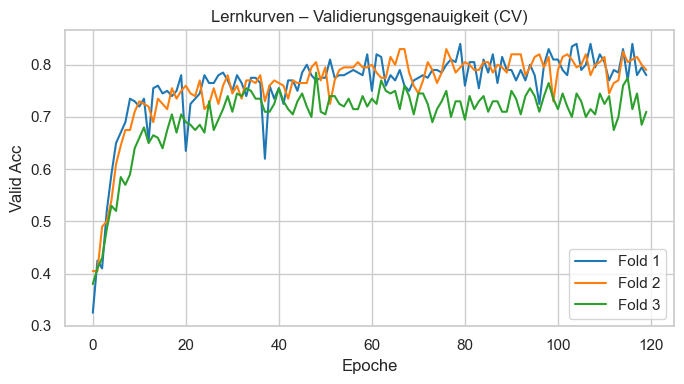

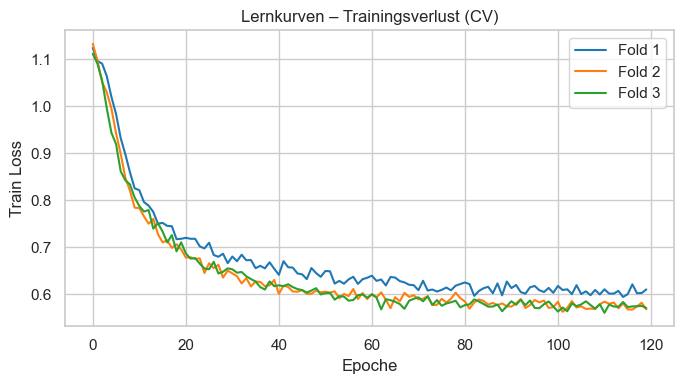

In [34]:
# Ausführen und Lernkurven plotten
fold_histories, fold_valid_acc, epochs_cv, W_cv, S_cv = cv_with_histories()

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("notebook"); sns.set_style("whitegrid")

# Validierungs-Accuracy pro Fold
plt.figure(figsize=(7,4))
for i, h in enumerate(fold_histories, 1):
    if h["valid_acc"]:
        plt.plot(h["valid_acc"], label=f"Fold {i}")
plt.title("Lernkurven – Validierungsgenauigkeit (CV)")
plt.xlabel("Epoche"); plt.ylabel("Valid Acc"); plt.legend()
plt.tight_layout(); plt.show()

# Trainingsverlust pro Fold
plt.figure(figsize=(7,4))
for i, h in enumerate(fold_histories, 1):
    plt.plot(h["train_loss"], label=f"Fold {i}")
plt.title("Lernkurven – Trainingsverlust (CV)")
plt.xlabel("Epoche"); plt.ylabel("Train Loss"); plt.legend()
plt.tight_layout(); plt.show()

### 6.4 Finales Training auf **allen** Daten + Lernkurve

Nach der Kreuzvalidierung trainieren wir ein **finales Modell** auf dem **gesamten Datensatz** (inkl. Augmentierung). Wir deaktivieren den Validierungs-Split, damit alle Daten zum Trainieren genutzt werden, und visualisieren die **Lernkurve (Train-Loss)**.

In [27]:
def train_final_model(epochs, config_override=None):
    # Konfiguration (identisch zu oben, kann überschrieben werden)
    config = config_override or {
        "model_name": "AttentionBaseNet",
        "n_splits": 3,
        "lr": 0.0005,
        "batch_size": 12,
        "max_epochs": 120,
        "kernel_length": 32,
        "F1": 24,
        "D": 6,
        "F2": 48,
        "dropout_rate": 0.5,
        "weight_decay": 0.005,
        "patience": 25,
        "augmentation_factor": 3,
        "filter_low": 0.5,
        "filter_high": 35.0,
        "label_smoothing": 0.15,
        "warmup_epochs": 10,
    }

    sfreq = epochs.info["sfreq"]
    epoch_length_s = epochs.times[-1] - epochs.times[0]
    window_size_samples = len(epochs.times)
    window_stride_samples = window_size_samples

    n_chans = epochs.info["nchan"]
    n_classes = len(epochs.event_id)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = get_model(
        model_name=config["model_name"],
        n_chans=n_chans,
        n_classes=n_classes,
        epoch_length_s=epoch_length_s,
        sfreq=sfreq,
        config=config,
    )

    # Augmentieren und Dataset bauen
    epochs_aug = augment_eeg_data(epochs, augment_factor=config["augmentation_factor"])
    dataset = create_from_mne_epochs(
        [epochs_aug],
        window_size_samples=window_size_samples,
        window_stride_samples=window_stride_samples,
        drop_last_window=False,
    )

    # Klassengewichte aus allen Daten
    import numpy as np
    from sklearn.utils.class_weight import compute_class_weight
    unique_targets = np.unique(epochs.metadata["target"])
    class_weights = compute_class_weight(
        "balanced", classes=unique_targets, y=epochs.metadata["target"]
    )

    clf = EEGClassifier(
        model,
        criterion=torch.nn.CrossEntropyLoss,
        criterion__weight=torch.FloatTensor([class_weights[i] for i in range(len(class_weights))]),
        criterion__label_smoothing=config["label_smoothing"],
        optimizer=torch.optim.AdamW,
        optimizer__lr=config["lr"],
        optimizer__weight_decay=config["weight_decay"],
        optimizer__betas=(0.9, 0.999),
        optimizer__eps=1e-8,
        batch_size=config["batch_size"],
        max_epochs=config["max_epochs"],
        train_split=None,  # gesamter Datensatz für Training
        device=device,
        classes=[0, 1, 2],
        callbacks=[
            ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=config["max_epochs"] - 1)),
        ],
        verbose=1,
    )

    print("\n=== Finales Training (alle Daten) ===")
    clf.fit(dataset, y=None)
    return clf, dataset, window_size_samples, window_stride_samples


Augmentiere Daten mit Faktor 3 (erweiterte Methoden)...


C:\Users\juliu\AppData\Local\Temp\ipykernel_20080\3005774805.py:188: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  augmented_epochs = mne.EpochsArray(


Daten augmentiert: 600 → 1800 Epochen

=== Finales Training (alle Daten) ===
  epoch    train_loss      lr     dur
-------  ------------  ------  ------
      1        1.1174  0.0005  7.0033
      2        1.0932  0.0005  7.4219
      3        1.0574  0.0005  8.5028
      4        0.9917  0.0005  8.8392
      5        0.9437  0.0005  9.0341
      6        0.8886  0.0005  8.8362
      7        0.8460  0.0005  10.0111
      8        0.8311  0.0005  9.6771
      9        0.8016  0.0005  11.0438
     10        0.7837  0.0005  10.3915
     11        0.7668  0.0005  9.7395
     12        0.7603  0.0005  10.7984
     13        0.7547  0.0005  9.7518
     14        0.7401  0.0005  11.5955
     15        0.7276  0.0005  10.2265
     16        0.7233  0.0005  12.1448
     17        0.7228  0.0005  10.8811
     18        0.7240  0.0005  12.0020
     19        0.6994  0.0005  10.6602
     20        0.6951  0.0005  15.7294
     21        0.6901  0.0005  15.9973
     22        0.6993  0.0005  13.814

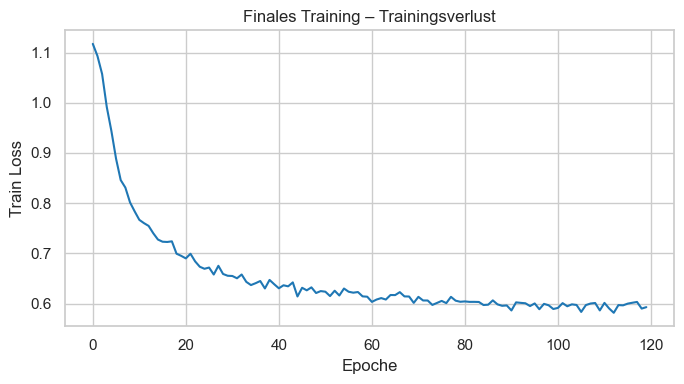

Finales Modell – Trainingsgenauigkeit (auf Fenstern): 0.9667
Konfusionsmatrix (Train):
[[475  14  36]
 [  1 630   8]
 [  0   1 635]]

Classification Report (Train):
              precision    recall  f1-score   support

      1-back       1.00      0.90      0.95       525
      2-back       0.98      0.99      0.98       639
      3-back       0.94      1.00      0.97       636

    accuracy                           0.97      1800
   macro avg       0.97      0.96      0.97      1800
weighted avg       0.97      0.97      0.97      1800


Hinweis: Für Generalisierung bitte unabhängiges Test-Set verwenden.


In [28]:
# Finales Training auf den bereits vorbereiteten Daten aus Abschnitt 4
final_clf, final_dataset, W_final, S_final = train_final_model(task_ready)

# Lernkurve (Train-Loss) des finalen Modells
plt.figure(figsize=(7,4))
plt.plot(final_clf.history[:, "train_loss"])
plt.title("Finales Training – Trainingsverlust")
plt.xlabel("Epoche"); plt.ylabel("Train Loss")
plt.tight_layout(); plt.show()

# Grobe Übersicht: Performance auf den Trainingsfenstern (optimistisch)
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

y_true_final = np.array([y for _, y, _ in final_dataset])
y_pred_final = final_clf.predict(final_dataset)
acc_final = accuracy_score(y_true_final, y_pred_final)
print(f"Finales Modell – Trainingsgenauigkeit (auf Fenstern): {acc_final:.4f}")
print("Konfusionsmatrix (Train):")
print(confusion_matrix(y_true_final, y_pred_final))
print("\nClassification Report (Train):")
print(classification_report(y_true_final, y_pred_final, target_names=["1-back","2-back","3-back"], zero_division=0))

print("\nHinweis: Für Generalisierung bitte unabhängiges Test-Set verwenden.")

In [29]:
# Überprüfe, ob das finale Modell auf den polaritären Datensatz (indoor vs. outdoor) angewendet werdenkann.
if SESSION_ID == "indoor":
    session_polar = "outdoor"
else:
    session_polar = "indoor"

try:
    polar_epochs, polar_baseline = load_and_prepare_data(SUBJECT=SUBJECT_ID, SESSION=session_polar)
    polar_norm = normalize_epochs_with_baseline(polar_epochs, polar_baseline, config=None)
    polar_ready = add_metadata_with_targets(polar_norm)
    print("Polaritäre Daten erfolgreich geladen und vorbereitet.")
    
    
    window_size_samples = len(polar_ready.times)

    window_stride_samples = window_size_samples
    # Erstelle Dataset für das finale Modell
    polar_dataset = create_from_mne_epochs(
        [polar_ready],
        window_size_samples=window_size_samples,
        window_stride_samples=window_stride_samples,
        drop_last_window=False,
    )
    
    y_true_polar = np.array([y for _, y, _ in polar_dataset])
    y_pred_polar = final_clf.predict(polar_dataset)
    acc_polar = accuracy_score(y_true_polar, y_pred_polar)
    
    print(f"\nFinales Modell – Genauigkeit auf polaren Daten (outdoor): {acc_polar:.4f}")
    print("Konfusionsmatrix (Polar):")
    print(confusion_matrix(y_true_polar, y_pred_polar))
    print("\nClassification Report (Polar):")
    print(classification_report(y_true_polar, y_pred_polar, target_names=["1-back","2-back","3-back"], zero_division=0))
except Exception as e:
    print(f"Fehler beim Laden/Verarbeiten der polaritären Daten: {e}") 

Loaded 595 task epochs.
Found 59 baseline epochs for normalization.

Normalisiere Daten anhand der Baseline mit erweiterten Filtern...
Normalisierung und Filterung abgeschlossen.

Metadaten mit 'target'-Spalte erfolgreich hinzugefügt.
Verwendetes direktes Mapping (Original-ID -> Target): {2: 0, 3: 1, 4: 2}
Events wurden auf 0, 1, 2 remapped
Beispiel-Metadaten:
   target
0       2
1       2
2       2
3       2
4       2
Polaritäre Daten erfolgreich geladen und vorbereitet.

Finales Modell – Genauigkeit auf polaren Daten (outdoor): 0.3529
Konfusionsmatrix (Polar):
[[ 36  74  62]
 [ 19  80 111]
 [ 13 106  94]]

Classification Report (Polar):
              precision    recall  f1-score   support

      1-back       0.53      0.21      0.30       172
      2-back       0.31      0.38      0.34       210
      3-back       0.35      0.44      0.39       213

    accuracy                           0.35       595
   macro avg       0.40      0.34      0.34       595
weighted avg       0.39    

### 6.5 Kanalbedeutung (8 Kanäle) – Okklusionsanalyse

Wir schätzen die **Bedeutung einzelner Kanäle**, indem wir Kanäle nacheinander **maskieren** (auf 0 skalieren) und den **Genauigkeitsabfall** gegenüber der Baseline messen. Größerer Abfall ⇒ höherer Einfluss.

In [22]:
def mask_channel_epochs(epochs, ch_idx, scale=0.0):
    data = epochs.get_data().copy()
    data[:, ch_idx, :] = data[:, ch_idx, :] * scale
    return mne.EpochsArray(
        data,
        epochs.info,
        events=epochs.events,
        tmin=epochs.tmin,
        event_id=epochs.event_id,
        metadata=epochs.metadata,
        verbose=False,
    )


def channel_importance_drop(clf, base_epochs, window_size_samples, window_stride_samples):
    import numpy as np
    from sklearn.metrics import accuracy_score

    # Baseline (unmaskiert)
    base_dataset = create_from_mne_epochs(
        [base_epochs],
        window_size_samples=window_size_samples,
        window_stride_samples=window_stride_samples,
        drop_last_window=False,
    )
    y_true = np.array([y for _, y, _ in base_dataset])
    base_pred = clf.predict(base_dataset)
    base_acc = accuracy_score(y_true, base_pred)

    # Kanalweise Maskierung
    n_chans = base_epochs.info["nchan"]
    drops = []
    for ch in range(n_chans):
        masked = mask_channel_epochs(base_epochs, ch, scale=0.0)
        masked_dataset = create_from_mne_epochs(
            [masked],
            window_size_samples=window_size_samples,
            window_stride_samples=window_stride_samples,
            drop_last_window=False,
        )
        pred = clf.predict(masked_dataset)
        acc = accuracy_score(y_true, pred)
        drops.append(base_acc - acc)
    return base_acc, np.array(drops)

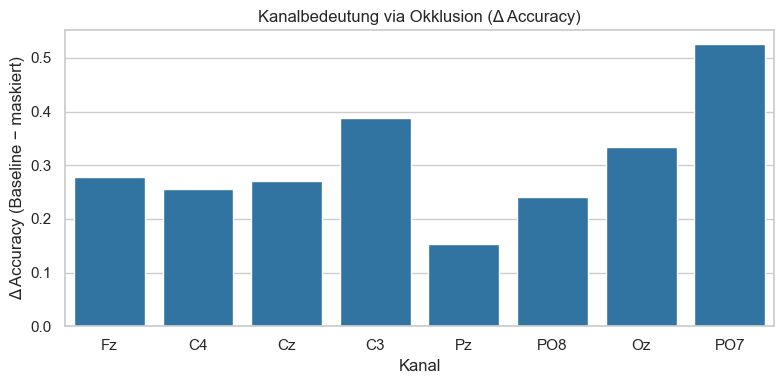

Baseline-Genauigkeit (unmaskiert): 0.9900
       PO7: ΔAcc = +0.5250
        C3: ΔAcc = +0.3883
        Oz: ΔAcc = +0.3333
        Fz: ΔAcc = +0.2783
        Cz: ΔAcc = +0.2700
        C4: ΔAcc = +0.2567
       PO8: ΔAcc = +0.2417
        Pz: ΔAcc = +0.1533

→ Wichtigster Kanal (größter Einfluss): PO7 (ΔAcc=+0.5250)

Anmerkung: Okklusion zeigt Sensitivität, nicht zwingend Kausalität. Für robustere Erklärungen ggf. Permutation Importance, Saliency, LRP, Integrated Gradients erwägen.


In [ ]:
# Kanalbedeutung mit dem finalen Modell auf den (unaugmentierten) vorbereiteten Epochen schätzen
base_acc, drops = channel_importance_drop(final_clf, task_ready, W_final, S_final)
ch_names = task_ready.info["ch_names"]

# Plot
plt.figure(figsize=(8,4))
sns.barplot(x=ch_names, y=drops)
plt.title("Kanalbedeutung via Okklusion (Δ Accuracy)")
plt.xlabel("Kanal"); plt.ylabel("Δ Accuracy (Baseline − maskiert)")
plt.tight_layout(); plt.show()

# Textuelle Analyse
order = np.argsort(-drops)
print(f"Baseline-Genauigkeit (unmaskiert): {base_acc:.4f}")
for i in order:
    print(f"{ch_names[i]:>10}: ΔAcc = {drops[i]:+.4f}")
if len(order):
    print(f"\n→ Wichtigster Kanal (größter Einfluss): {ch_names[order[0]]} (ΔAcc={drops[order[0]]:+.4f})")

print("\nAnmerkung: Okklusion zeigt Sensitivität, nicht zwingend Kausalität. Für robustere Erklärungen ggf. C")

### 6.6 Erweiterte Elektroden-Attributionsmethoden (Permutation, Saliency, Integrated Gradients, LRP-Proxy)

Die folgenden Zellen ergänzen die Kanal-Analyse um vier gängige Ansätze:
- **Permutation Importance**: Kanalweise Permutation über Fenster → Δ Accuracy.
- **Saliency (|∂logit/∂x|)**: Gradienten-basierte Sensitivität je Kanal.
- **Integrated Gradients (IG)**: Integrierte Gradienten entlang Zero-Baseline.
- **LRP-Proxy (Gradient×Input)**: Ein pragmatisches, LRP-ähnliches Maß. _Echtes LRP_ erfordert spezialisierte Implementierungen (z. B. Captum LayerLRP) und model-/layer-spezifische Regeln; hier nutzen wir **Gradient×Input** als sinnvolle Approximation.

> **Hinweise**
> - Es wird das bereits trainierte `final_clf` verwendet und die nicht-augmentierten Epochen `task_ready`.
> - Für die Analysen wird ein handliches Teil-Set an Fenstern genutzt (Parameter `MAX_WINDOWS`).

In [24]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("notebook"); sns.set_style("whitegrid")

# ---- Hilfsfunktionen ----

def prepare_analysis_windows(epochs, window_size_samples, window_stride_samples, max_windows=256):
    ds = create_from_mne_epochs(
        [epochs],
        window_size_samples=window_size_samples,
        window_stride_samples=window_stride_samples,
        drop_last_window=False,
    )
    n = len(ds)
    take = min(max_windows, n)
    # gleichmäßig sampeln
    idx = np.linspace(0, n-1, take, dtype=int)
    X = np.stack([ds[i][0] for i in idx])  # (N, C, T)
    y = np.array([ds[i][1] for i in idx], dtype=int)
    return X.astype(np.float32), y, ds


def plot_bar(values, labels, title, ylabel):
    plt.figure(figsize=(8,4))
    ax = sns.barplot(x=labels, y=values)
    ax.set_title(title); ax.set_xlabel("Kanal"); ax.set_ylabel(ylabel)
    plt.xticks(rotation=0)
    plt.tight_layout(); plt.show()


# Daten vorbereiten
MAX_WINDOWS = 256
X_win, y_win, _ = prepare_analysis_windows(task_ready, W_final, S_final, max_windows=MAX_WINDOWS)
ch_names = task_ready.info["ch_names"]
assert X_win.ndim == 3, X_win.shape

# Baseline-Accuracy auf dem Analyse-Set
from sklearn.metrics import accuracy_score
base_pred = final_clf.predict(X_win)
base_acc_analysis = accuracy_score(y_win, base_pred)
print(f"Baseline-Accuracy (Analyse-Set, {len(X_win)} Fenster): {base_acc_analysis:.4f}")

Baseline-Accuracy (Analyse-Set, 256 Fenster): 0.9961


#### 6.6.1 Permutation Importance (kanalweise)

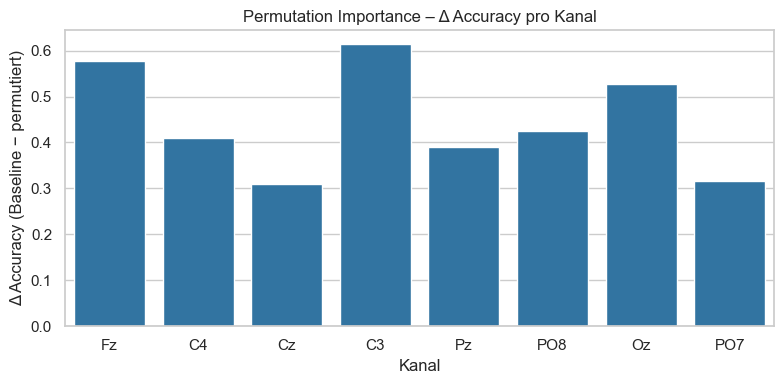

Ranking (Permutation Importance):
        C3: ΔAcc = +0.6133
        Fz: ΔAcc = +0.5781
        Oz: ΔAcc = +0.5273
       PO8: ΔAcc = +0.4258
        C4: ΔAcc = +0.4102
        Pz: ΔAcc = +0.3906
       PO7: ΔAcc = +0.3164
        Cz: ΔAcc = +0.3086


In [25]:
rng = np.random.default_rng(42)
C = X_win.shape[1]
perm_drops = []
for c in range(C):
    Xp = X_win.copy()
    perm_idx = rng.permutation(len(Xp))
    # permutiere nur Kanal c über die Fenster, Zeitstruktur bleibt erhalten
    Xp[:, c, :] = Xp[perm_idx, c, :]
    pred = final_clf.predict(Xp)
    acc = accuracy_score(y_win, pred)
    perm_drops.append(base_acc_analysis - acc)
perm_drops = np.array(perm_drops)

plot_bar(perm_drops, ch_names, "Permutation Importance – Δ Accuracy pro Kanal", "Δ Accuracy (Baseline − permutiert)")
order = np.argsort(-perm_drops)
print("Ranking (Permutation Importance):")
for i in order:
    print(f"{ch_names[i]:>10}: ΔAcc = {perm_drops[i]:+.4f}")

#### 6.6.2 Saliency (|∂logit/∂x|) pro Kanal

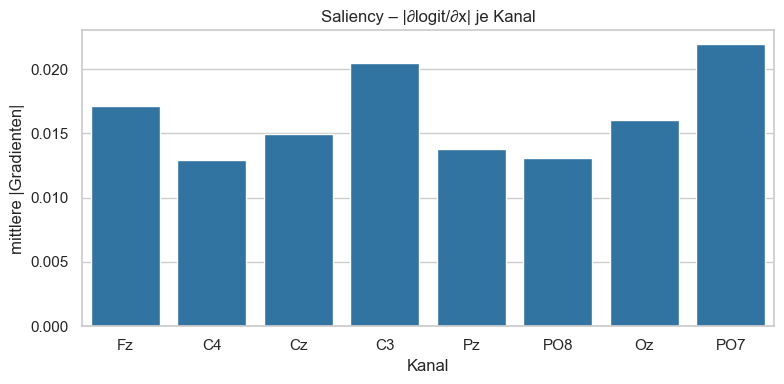

Ranking (Saliency):
       PO7: score = 0.021905
        C3: score = 0.020452
        Fz: score = 0.017151
        Oz: score = 0.016035
        Cz: score = 0.014940
        Pz: score = 0.013760
       PO8: score = 0.013117
        C4: score = 0.012944


In [26]:
module = final_clf.module_.eval()
device = next(module.parameters()).device

Xt = torch.tensor(X_win, dtype=torch.float32, device=device, requires_grad=True)
with torch.enable_grad():
    logits = module(Xt)               # (N, K)
    preds = logits.argmax(dim=1)      # (N,)
    chosen = logits[torch.arange(Xt.size(0), device=device), preds]
    loss = chosen.sum()
    module.zero_grad(set_to_none=True)
    if Xt.grad is not None:
        Xt.grad.zero_()
    loss.backward()
    grads = Xt.grad.detach().abs().cpu().numpy()  # (N, C, T)

saliency_per_channel = grads.mean(axis=(0,2))
plot_bar(saliency_per_channel, ch_names, "Saliency – |∂logit/∂x| je Kanal", "mittlere |Gradienten|")
order = np.argsort(-saliency_per_channel)
print("Ranking (Saliency):")
for i in order:
    print(f"{ch_names[i]:>10}: score = {saliency_per_channel[i]:.6f}")

#### 6.6.3 Integrated Gradients (Zero-Baseline)

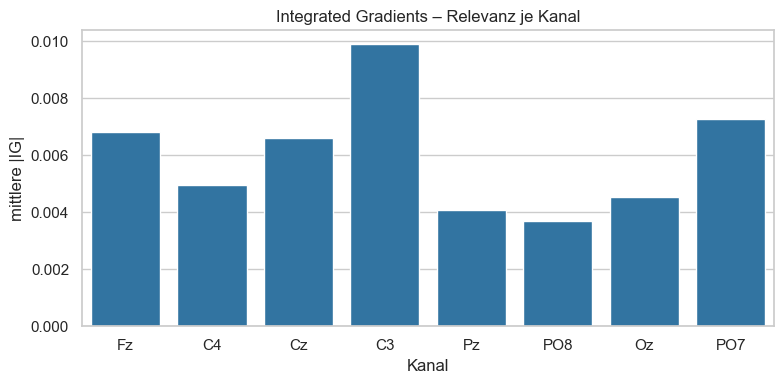

Ranking (Integrated Gradients):
        C3: score = 0.009886
       PO7: score = 0.007261
        Fz: score = 0.006820
        Cz: score = 0.006612
        C4: score = 0.004950
        Oz: score = 0.004534
        Pz: score = 0.004082
       PO8: score = 0.003677


In [27]:
def integrated_gradients(module, X, steps=32):
    """Einfaches IG über Zero-Baseline für jeweilige vorhergesagte Klasse.
    X: torch.Tensor (N, C, T) auf device, **ohne** requires_grad
    """
    module.eval()
    baseline = torch.zeros_like(X)
    attributions = torch.zeros_like(X)
    for k in range(1, steps+1):
        alpha = float(k) / steps
        Xi = baseline + alpha * (X - baseline)
        Xi.requires_grad_(True)
        logits = module(Xi)
        preds = logits.argmax(dim=1)
        chosen = logits[torch.arange(Xi.size(0), device=Xi.device), preds]
        module.zero_grad(set_to_none=True)
        if Xi.grad is not None:
            Xi.grad.zero_()
        chosen.sum().backward()
        attributions = attributions + Xi.grad.detach()
    avg_grads = attributions / steps
    ig = (X - baseline) * avg_grads
    return ig

with torch.no_grad():
    Xig = torch.tensor(X_win, dtype=torch.float32, device=device)
ig_attr = integrated_gradients(module, Xig, steps=32)  # (N, C, T)
ig_attr = ig_attr.abs().detach().cpu().numpy()
ig_per_channel = ig_attr.mean(axis=(0,2))

plot_bar(ig_per_channel, ch_names, "Integrated Gradients – Relevanz je Kanal", "mittlere |IG|")
order = np.argsort(-ig_per_channel)
print("Ranking (Integrated Gradients):")
for i in order:
    print(f"{ch_names[i]:>10}: score = {ig_per_channel[i]:.6f}")

#### 6.6.4 LRP (Proxy: Gradient×Input)

_Echtes LRP_ benötigt layer-spezifische Regeln (z. B. ε-/γ-Regel) und eine Implementierung, die die Architektur exakt unterstützt. Als praktikables Proxy-Maß nutzen wir **Gradient×Input**, das häufig ähnlich interpretierbare Muster liefert. Für echtes LRP kannst du z. B. mit **Captum** `LayerLRP` arbeiten (sofern kompatibel) und zielgerichtet eine Layer-Hook-Strategie wählen.

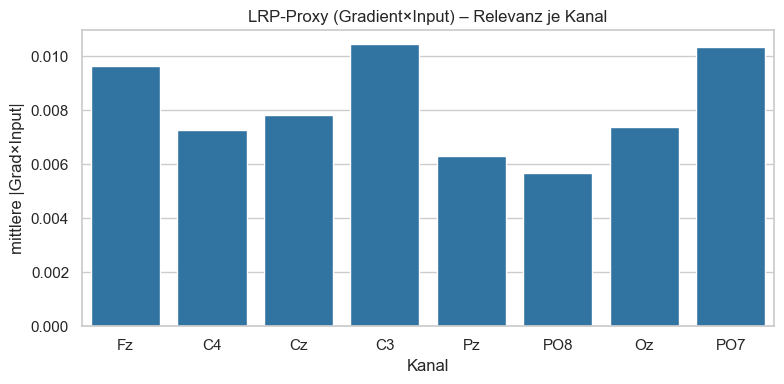

Ranking (LRP-Proxy):
        C3: score = 0.010442
       PO7: score = 0.010344
        Fz: score = 0.009663
        Cz: score = 0.007847
        Oz: score = 0.007386
        C4: score = 0.007262
        Pz: score = 0.006296
       PO8: score = 0.005662


In [28]:
module.eval()
Xt = torch.tensor(X_win, dtype=torch.float32, device=device, requires_grad=True)
with torch.enable_grad():
    logits = module(Xt)
    preds = logits.argmax(dim=1)
    chosen = logits[torch.arange(Xt.size(0), device=device), preds]
    module.zero_grad(set_to_none=True)
    if Xt.grad is not None:
        Xt.grad.zero_()
    chosen.sum().backward()
    gxi = (Xt.grad * Xt).detach().abs().cpu().numpy()  # (N, C, T)

lrp_proxy_per_channel = gxi.mean(axis=(0,2))
plot_bar(lrp_proxy_per_channel, ch_names, "LRP-Proxy (Gradient×Input) – Relevanz je Kanal", "mittlere |Grad×Input|")
order = np.argsort(-lrp_proxy_per_channel)
print("Ranking (LRP-Proxy):")
for i in order:
    print(f"{ch_names[i]:>10}: score = {lrp_proxy_per_channel[i]:.6f}")

## 7) Artefakte & Export

In [29]:
from datetime import datetime
summary = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "val_acc_per_fold": [float(x) for x in (results or [])],
    "mean_val_acc": float(np.mean(results)) if results else None,
    "std_val_acc": float(np.std(results)) if results else None,
}
import json
Path("summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print("summary.json gespeichert.")
print("Logfile:", str(Path("run.log").resolve()))

summary.json gespeichert.
Logfile: D:\Git\Repository\eeg-brain-interface\notebooks\run.log


## 8) Tipps zur Weiterarbeit (ohne Logikänderung)

- **Seed/Determinismus**: Für reproduzierbare CV-Läufe Seeds (NumPy, PyTorch, Python) zentral setzen.
- **Lernkurven je Epoche**: Optional History-Serialisierung/Callbacks für detailliertere Plots (Loss/Acc vs. Epoche) – modular ergänzbar.
- **Tracking**: W&B oder MLflow integrieren (separate Zellen), ohne Kernlogik umzuschreiben.
- **Datenpfade**: Parameter-Cell für flexible Dateiauswahl.


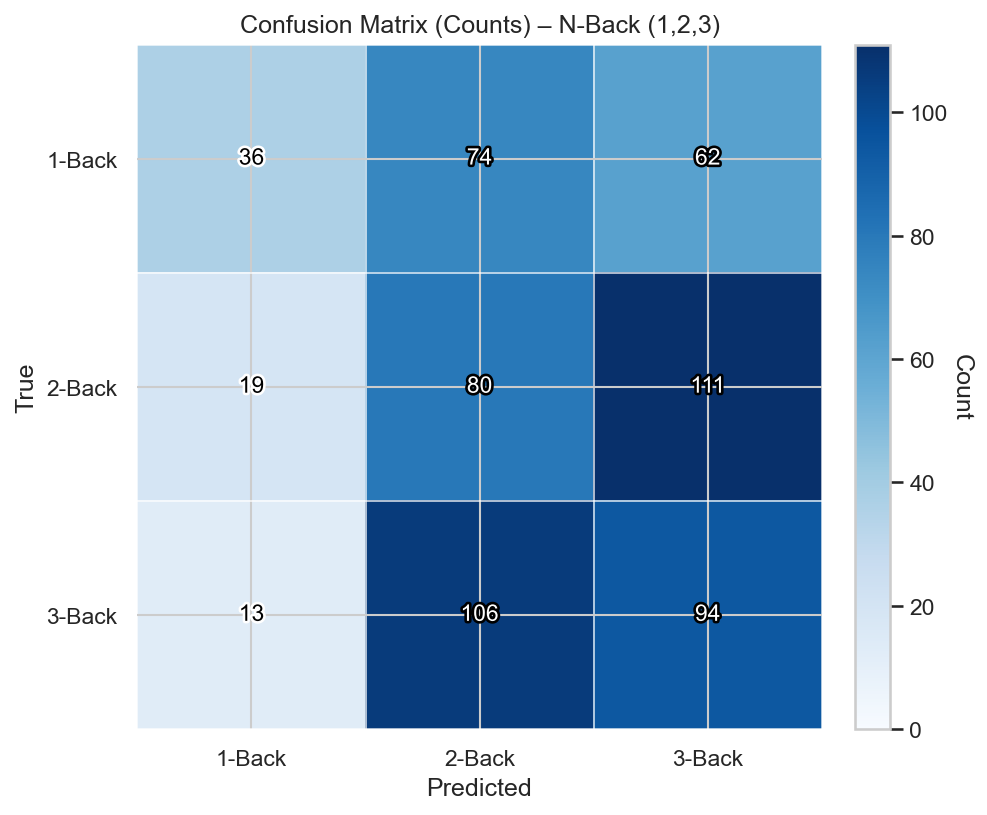

In [40]:
# Bonus Skript: Plot Konfusionsmatrix

def plot_confusion_matrix_pretty(cm, labels=None, normalize=False, title=None, savepath=None):
    """
    Konfusionsmatrix mit:
    - 0-Wert = reines Weiß
    - hell-zu-satt verlaufender Colormap
    - Zahlen in allen Zellen mit kontrastadaptiver Farbe + Outline
    - dezenten Gridlines
    """
    import numpy as _np
    import matplotlib as _mpl
    import matplotlib.patheffects as _pe
    from matplotlib.colors import ListedColormap

    cm = _np.asarray(cm)
    assert cm.ndim == 2 and cm.shape[0] == cm.shape[1], "cm muss quadratisch sein"

    if labels is None:
        labels = ['1-Back', '2-Back', '3-Back']  # Mapping: Klasse 0/1/2 → 1/2/3-Back

    data = cm.astype(float)
    if normalize:
        row_sums = data.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        data = data / row_sums

    fig, ax = plt.subplots(figsize=(6.8, 5.6), dpi=150)

    # --- Colormap: Basis Viridis, aber exakter 0-Wert wird rein weiß ---
    base = plt.get_cmap('Blues')  # Alternativ: 'YlGnBu', 'Blues', 'PuBu'
    colors = base(_np.linspace(0, 1, 256))
    cmap = ListedColormap(colors)

    vmin = 0.0
    vmax = data.max() if normalize else float(cm.max())
    norm = _mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    im = ax.imshow(data, cmap=cmap, norm=norm, aspect='equal')

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel('Proportion' if normalize else 'Count', rotation=270, labelpad=12)

    # Achsen & Labels
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title or ('Confusion Matrix (normalized)' if normalize else 'Confusion Matrix (Counts)'))

    # Dezente Gridlines
    n = data.shape[0]
    ax.set_xticks(_np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(_np.arange(-0.5, n, 1), minor=True)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=0.8, alpha=0.8)
    ax.tick_params(which='minor', bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Zahlen in alle Zellen (Kontrast + Outline)
    fmt = '.2f' if normalize else 'd'
    for i in range(n):
        for j in range(n):
            shown_val = data[i, j] if normalize else cm[i, j]
            # Helligkeits-Proxy über Norm-Wert der Zelle
            norm_val = norm(data[i, j])
            txt_color = 'black' if norm_val < 0.55 else 'white'
            outline = 'white' if txt_color == 'black' else 'black'
            ax.text(
                j, i, format(shown_val, fmt),
                ha='center', va='center', fontsize=11, color=txt_color,
                path_effects=[_pe.withStroke(linewidth=2.5, foreground=outline)]
            )

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
    return fig, ax


# === Beispiel mit deiner Matrix ===
cm = np.array([[ 36,  74,  62],
                [ 19,  80, 111],
                [ 13, 106,  94]])

labels = ['1-Back', '2-Back', '3-Back']  # Klasse 0/1/2 → 1/2/3-Back

plot_confusion_matrix_pretty(cm, labels=labels, normalize=False,
                             title='Confusion Matrix (Counts) – N-Back (1,2,3)')
plt.show()

# Optional: Normalisierte Ansicht
# plot_confusion_matrix_pretty(cm, labels=labels, normalize=True,
#                              title='Confusion Matrix (Normalized) – N-Back (1,2,3)')
# plt.show()

